In [4]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os

datadir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/NEWData/'
datadirAlt  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MonomerMeasurements/NEWData/'
plotsdir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [5]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        #print(i)
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]

In [6]:
cmap0 = plt.cm.get_cmap('YlOrBr') #YlOrBr
clrs1= ['#edf8b1','#7fcdbb','#2c7fb8']
clrs2=['#f7fcb9','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['#e7e1ef','#c994c7','#dd1c77']

clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','dimgrey']
#clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']
clrs1= ['grey','#7fcdbb','#2c7fb8']
clrs2=['grey','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['grey','#c994c7','#dd1c77']
clrs_div = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
clrrrs=[clrs1,clrs3,clrs2]

#'YlOrBr'
ClrsRici = ["#96a2c1ff","#999ebeff","#a697baff","#b795afff","#c996a8ff","#d398a5ff"]
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosen = ["#7883acff","#73457aff","#b25268ff"] #
#ClrsRici =["#a66181ff","#d49995ff"] #ClrsRici  ClrsRici #["#7883acff","#73457aff","#b25268ff","#d49995ff"]
ClrsOrange = ["#fed98e","#fe9929","#d95f0e","#993404"]

[14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]


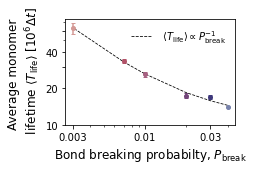

In [9]:
fig2,ax2 = plt.subplots(1,figsize = (3.5,2.3))

f=3
MP = "0.12 0.1 0.06 0.03 0.02 0.01".split() # ORIGINAL RANGE  0.12 0.1 0.06 0.03 0.02 0.01
BP = "0.04 0.03 0.02 0.01 0.007 0.003".split() # ORIGINAL RANGE 0.04 0.03 0.02 0.01 0.007 0.003
seeds= "1 3 5".split()
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
AvTmonlife = []
StdTmonlife = []
AvLargestComps = []
for f in range(len(MP)):
    IndividualT_MonRelase = []
    LargestCompsEnd = []
    Tmonlife = []
    for s in range(len(seeds)):
        RateMons = []
        RateMonsRel = []
        RateMonsInc = []
        #Time NumMons RateMons LargestComp
        filename = 'monomerdata_BP'+BP[f]+'_S'+seeds[s]+'.dat'
        MonData = pandas.read_csv(datadirAlt+filename, header = 'infer',sep=' ')
        Time_ = MonData.Time
        NumMons_ = MonData.NumMons
        RateMons_ = MonData.RateMons
        LargestComp_ = MonData.LargestComp
        Time,NumMons,RateMons,LargestComp =Time_.values,NumMons_.values,RateMons_.values,LargestComp_.values
        if len(Time)>0:
            if Time[-1] >0.6e6:
                #for tt in range(len(Time)-1):
                #    RateMons.append((NumMons[tt+1]-NumMons[tt])/(Time[tt+1]-Time[tt]))
                AvNumMons = np.mean(NumMons[:]) #int(len(RateMons)/4)
                NumInNetwork = 6330-AvNumMons
                AverageT_MonRelease = np.divide(1,np.mean(np.abs(RateMons[:]))) #int(len(RateMons)/4)
                IndividualT_MonRelase.append(np.divide(AverageT_MonRelease * NumInNetwork,10**6))

                N=6
                rollingRatAv = np.convolve(np.abs(np.ravel(RateMons)), np.ones(N)/N, mode='valid')
                timeRol = Time[int(N/2)+1:-int(N/2-1)]
                idx = (np.abs(Time - 1509600)).argmin()
                LargestCompsEnd.append(LargestComp[idx])
                Tmonlife.append(IndividualT_MonRelase)
    AvTmonlife.append(np.mean(Tmonlife))
    StdTmonlife.append(np.std(Tmonlife))
    AvLargestComps.append(np.mean(LargestCompsEnd))
    ax2.errorbar(BPsV[f],np.mean(IndividualT_MonRelase),yerr = np.std(IndividualT_MonRelase),capsize = 2,color = ClrsRici[f],marker = 'o',markersize = 4) ##Would this by x2??
    #ax2.plot(BPsV[f],np.divide(np.mean(IndividualT_MonRelase),10**6),color = clrs_5[f],marker = 'o',markersize = 10) ##Would this by x2??
    #print(MP[f],np.mean(IndividualT_MonRelase),np.std(IndividualT_MonRelase))
#ax[2].set_ylabel("Free monomer lifetime",fontsize = 12)
ax2.set_ylabel("Average monomer \n lifetime"+r" $ \langle T_{\mathrm{life}}\rangle$ [$10^6\Delta t$]",fontsize = 12)
ax2.set_xlabel("Bond breaking probabilty, $P_{\mathrm{break}}$",fontsize = 12)
#ax2.set_yscale('log')
text = r" $ \langle T_{\mathrm{life}}\rangle \propto P_{\mathrm{break}}^{-1}$"
#ax2.set_ylim([0,350])
print(AvTmonlife)
fig2.tight_layout()
x1,y1 = np.array(np.divide(1,BPsV)),np.array(AvTmonlife)
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax2.plot(np.divide(1,x1),m1*x11+b1,color = 'black',linestyle = '--',linewidth = 0.8,label = text)
ax2.legend(fontsize = 10,loc = 'upper right',frameon=False)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yticks([10,20,30,40,60],['10','20','','40',''])
ax2.set_xticks([0.003,0.01,0.03],['0.003','0.01','0.03'])
#ax.set_ylim([70,100])
plotname = "EquilibriumMaster.pdf"
#fig.savefig(plotsdir+plotname)

plotname2 = "MonomerExchangeMasterNEW.pdf"
fig2.savefig(plotsdir+plotname2)
##plotname = "Equilibration_quants.pdf"


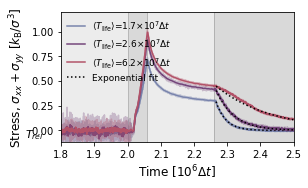

In [10]:
fig,ax = plt.subplots(1,figsize = (4.3,2.7))


xstretches = "102".split()
MPs = "0.1 0.03 0.01".split()
BPs = "0.03 0.01 0.003".split()

lenT0 = 101222
lenT1 = 3272



timeFactor = 10**6
t_Eq = (2000000*0.5)/timeFactor
t_MT = (2000000*0.5)/timeFactor +t_Eq
#endOfEq = 1509600
t_strain = ((40000+20000)/timeFactor)+t_MT
t_InitRel = 20000*10/timeFactor+t_strain
#t_addmons = 1000/timeFactor +t_InitRel
t_FulLRel = 1000000/timeFactor+t_InitRel

times = [0,t_Eq,t_MT,t_strain,t_InitRel,t_FulLRel]
#strains=[0,0,0,100,100,100]
UP,LW=-0.15,1.2
#ax.plot(times,strains,linestyle = '-',color = 'black')
ax.fill_between([0,t_Eq],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
ax.fill_between([t_MT,t_strain],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
ax.fill_between([t_Eq,t_MT],[LW,LW],[UP,UP],alpha = 0.15,color = 'grey')
ax.fill_between([t_strain,t_InitRel],[LW,LW],[UP,UP],alpha = 0.15,color = 'grey')
ax.fill_between([t_InitRel,t_FulLRel],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
x=0
ax.set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
TmonAv = [1.7,2.6,6.2]
#Tmonstd = np.divide([3.571501191030219,5.480583457304206,13.19089058082929],10)
mrks = [":","-","--"]
alphs = [0.5,0.5,0.5]
Avtaus = []
Stdtaus = []
Vol1 = 51*51*12
Vol2 = (51+int(xstretches[x]))*(51+int(xstretches[x]))*12-Vol1
for p in range(len(MPs)):
    filename = 'stressdata_BP'+BPs[p]+'.dat'
    
    StressData = pandas.read_csv(datadir+filename, header = 'infer',sep=' ')
    Time_ = StressData.Time
    stressTotAv_ = StressData.stressAv
    stressTotAv,Time = stressTotAv_.values,Time_.values
    rollingAvRelax = np.convolve(stressTotAv[lenT0+lenT1:], np.ones(N)/N, mode='valid')
    timePostStretch = np.add(Time[lenT0+lenT1:],-Time[lenT0+lenT1])[int(N/2):-int(N/2-1)]
    stressPostStretch = rollingAvRelax
    ax.plot(timePostStretch,stressPostStretch,color = 'black')
    phi_inf = 0
    phi0 = stressPostStretch[10]
    phiTau = phi0/np.exp(1)
    tau = timePostStretch[intersection(stressPostStretch,phiTau)[0]]
    phiTheory = []
    for tt in range(len(timePostStretch)):
        t = timePostStretch[tt]
        phiTheory.append(phiform(phi0,phi_inf,tau,t))
    
    ax.plot(np.divide(Time,timeFactor),stressTotAv,color = ClrsRiciChosen[p],alpha =0.3)
    #print(len(stressTotAv))
    #ax.plot(np.divide(Time[lenT0+lenT1:],timeFactor),stressTotAv[lenT0+lenT1:],color = 'black',alpha =0.3)
    N=50
    rollingAv = np.convolve(stressTotAv, np.ones(N)/N, mode='valid')
        #rollingAvY = np.convolve(stressY, np.ones(N)/N, mode='valid')
    timeAv = Time[int(N/2):-int(N/2-1)]
            
    ax.plot(np.divide(timeAv,timeFactor),rollingAv,color = ClrsRiciChosen[p],linestyle = '-',label = r'$\langle T_{\mathrm{life}}\rangle$='+str(TmonAv[p])+r'$\times10^7\Delta t$')
    if p==2:
        ax.plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black',label = 'Exponential fit')
    else:
        ax.plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black')

    tauAxis = np.add(np.divide(tau,timeFactor),t_InitRel)
    #print(t_strain)
    # if p==0:
    #     ax.plot([tauAxis,tauAxis],[-0.13,0.04],linestyle = '-.',color = 'black')
    # if p==1:
    #     ax.plot([tauAxis,tauAxis],[-0.13,0.09],linestyle = '-.',color = 'black')
    # if p==2:
    #     ax.plot([tauAxis,tauAxis],[-0.13,0.12],linestyle = '-.',color = 'black')
text2 = r"$T_{rel}$"
ax.text(1.69,-0.07,text2,color = 'black',fontsize = 11)
ax.set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax.set_xlim([1.8,2.5])
ax.set_ylim([-0.12,1.2])
ax.legend(frameon=False,loc = [0.01,0.43],fontsize = 9)
fig.tight_layout()
plotname = "Stress_relaxation.pdf"
#fig.savefig(plotsdir + plotname)

In [11]:
#OtherData

#Avtaus =[14234.0, 17030.666666666668, 21329.333333333332, 38244.666666666664, 48664.666666666664, 150533.33333333334] 
#Stdtaus= [2172.0, 2103.1102892832055, 1442.1413091495422, 4186.233098569113, 5931.628519124313, 10291.6670931174]
Avtaus =[53393.333333333336, 66820.0, 66666.66666666667, 92110.0, 124960.0, 224523.33333333334] 
Stdtaus= [3762.1831723378677, 4456.037103376348, 3174.6320871699277, 0.0, 30741.642766774843, 85280.2768653]
#TmonAv = [3,6,26]
#Tmonstd = np.divide([3.571501191030219,5.480583457304206,13.19089058082929],10)

## Plotting master T Vs T plot

[14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]
[0.02153922135383837, 0.7248736871105754, 0.8129193999286023, 1.1557439454442404, 1.3577575845457819, 6.299237673061252]


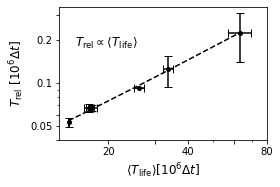

In [12]:
fig,ax = plt.subplots(1,figsize = (4.,2.7))
print(AvTmonlife)
print(StdTmonlife)
#y=mc+c
#0.15*20000 [0.01,0.15]
x1,y1 = np.array(AvTmonlife),np.array(Avtaus)
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax.errorbar(AvTmonlife,np.divide(Avtaus,10**6),xerr = StdTmonlife,yerr = np.divide(Stdtaus,10**6),color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,10**6),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
#ax.plot([20,300],[0.0005*20,0.0005*300],linestyle = '--',color = 'black') #ClrsOrange[3])
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
ax.text(15,0.18,text,color = 'black',fontsize = 12)
#---- log-log axis---#
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks([20,30,40,60,80],['20','','40','','80'])
ax.set_yticks([0.04,0.05,0.06,0.1,0.2,0.3],['','0.05','','0.1','0.2',''])
#---- normal axis ----#
#ax.set_xticks([100,200,300,400],['100','200','300','400'])
#ax.set_yticks([0.05,0.1,0.15],['0.05','0.1','0.15'])

fig.tight_layout()
plotname = 'Master_tau_vs_Tlife.pdf'
fig.savefig(plotsdir+plotname)

# LargestComp = np.divide(AvLargestComps,6330)
# #print(LargestComp-)
# norm = TwoSlopeNorm(vmin=85, vcenter=92.5,vmax=100)
# fig2,ax2 = plt.subplots(1,figsize = (4.5,2.6))
# for i in range(len(Avtaus)):
#     ax2.errorbar(AvTmonlife[i],np.divide(Avtaus[i],10**6),xerr = StdTmonlife[i],yerr = np.divide(Stdtaus[i],10**6),color =cmap0((LargestComp[i]-0.85)/(0.15)), linestyle = '',marker = 'o',markersize = 4,capsize = 4)
#     print("LC",LargestComp[i])
#     print((LargestComp[i]-0.7)/(0.3))
# ax2.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
# ax2.set_ylabel(r"$\tau_{rel}$ [$10^6\Delta t$]",fontsize = 12)

# ax2.set_yscale('log')
# ax2.set_xscale('log')
# ax2.set_xticks([50,60,100,200,300,400],['50','','100','200','','400'])
# ax2.set_yticks([0.03,0.04,0.06,0.12],['0.03','','0.06','0.12'])
# fig2.show()
# fig2.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap0),ax=ax2, label = '% in largest graph')
# fig2.tight_layout()

# #fig2.savefig(plotsdir+plotname2)

In [31]:
KrodTaus = [20320.0, 44273.333333333336, 98460.0] #[21680.0, 40333.333333333336, 96373.33333333333]
KrodTausErr = [80.0, 674.1579109443787, 2655.8279730099657]
KrodLifetimes =[18.88107242, 26.1079433 , 65.34975802]
KrodLifetimesErr = [1.41499218, 0.91113072, 0.4366159 ]

DomeLifetimes = [ 19.85123265 , 35.02019844 , 40.8739017 ,  68.22514254 , 82.22431073, 192.60845566]
DomeTaus = [ 31980.,  34880. , 44140.,  67860.,  99980. ,203360.]
#[ 19240. , 20640. , 23720. , 40000. , 52000., 119320.]
#[14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]

kappaTaus = [14234.0, 17030.666666666668, 21329.333333333332]
kappaLifetimes = [17.52835304 ,24.93518172 ,61.29644224]
kappaLifetimesErr = [1.31047698 ,0.66528604 ,2.97269024]

[14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]
[0.02153922135383837, 0.7248736871105754, 0.8129193999286023, 1.1557439454442404, 1.3577575845457819, 6.299237673061252]
[14.136435110367358, 16.914355090988998, 17.330893216723926, 26.142224446579256, 33.7174924816437, 62.94111858793398]
[0.02153922135383837, 0.7248736871105754, 0.8129193999286023, 1.1557439454442404, 1.3577575845457819, 6.299237673061252]


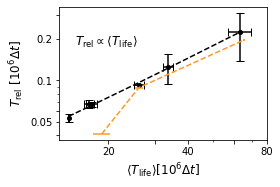

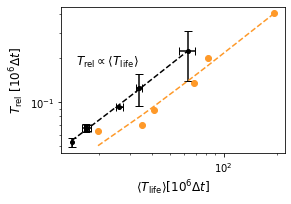

In [32]:
fig,ax = plt.subplots(1,figsize = (4.,2.7))
print(AvTmonlife)
print(StdTmonlife)
MultiFactor = 2
#y=mc+c
#0.15*20000 [0.01,0.15]
x1,y1 = np.array(AvTmonlife),np.array(Avtaus)
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax.errorbar(AvTmonlife,np.divide(Avtaus,10**6),xerr = StdTmonlife,yerr = np.divide(Stdtaus,10**6),color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,10**6),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
ax.errorbar(KrodLifetimes,np.divide(np.multiply(KrodTaus,MultiFactor),10**6),yerr = np.divide(KrodTausErr,10**6),xerr = KrodLifetimesErr,color = ClrsOrange[1],linestyle = '--',label = r'KROD')
#ax.plot([20,300],[0.0005*20,0.0005*300],linestyle = '--',color = 'black') #ClrsOrange[3])
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
ax.text(15,0.18,text,color = 'black',fontsize = 12)
#---- log-log axis---#
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks([20,30,40,60,80],['20','','40','','80'])
ax.set_yticks([0.04,0.05,0.06,0.1,0.2,0.3],['','0.05','','0.1','0.2',''])
#---- normal axis ----#
#ax.set_xticks([100,200,300,400],['100','200','300','400'])
#ax.set_yticks([0.05,0.1,0.15],['0.05','0.1','0.15'])

fig.tight_layout()
plotname = 'Master_tau_vs_Tlife_KROD.pdf'
#fig.savefig(plotsdir+plotname)







# fig,ax = plt.subplots(1,figsize = (4.,2.7))
# print(AvTmonlife)
# print(StdTmonlife)
# #y=mc+c
# #0.15*20000 [0.01,0.15]
# x1,y1 = np.array(AvTmonlife),np.array(Avtaus)
# m1,b1 = np.polyfit(x1,y1,1)
# x11 = x1.reshape(-1,1)
# a1,_,_,_ = np.linalg.lstsq(x11, y1)
# ax.errorbar(AvTmonlife,np.divide(Avtaus,10**6),xerr = StdTmonlife,yerr = np.divide(Stdtaus,10**6),color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
# ax.plot(x1,np.divide(m1*x1+b1,10**6),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
# ax.plot(KrodLifetimes,np.divide(np.multiply(KrodTaus,10),10**6),color = ClrsOrange[1],linestyle = '--',label = r'KROD')
# #ax.plot([20,300],[0.0005*20,0.0005*300],linestyle = '--',color = 'black') #ClrsOrange[3])
# ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
# ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

# text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
# text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
# ax.text(15,0.18,text,color = 'black',fontsize = 12)
# #---- log-log axis---#
# #ax.set_yscale('log')
# #ax.set_xscale('log')
# ax.set_xticks([20,30,40,60,80],['20','','40','','80'])
# ax.set_yticks([0.04,0.05,0.06,0.1,0.2,0.3],['','0.05','','0.1','0.2',''])
# #---- normal axis ----#
# #ax.set_xticks([100,200,300,400],['100','200','300','400'])
# #ax.set_yticks([0.05,0.1,0.15],['0.05','0.1','0.15'])

# fig.tight_layout()
# fig.tight_layout()
# plotname = 'Master_tau_vs_Tlife_Kappa.pdf'
# #fig.savefig(plotsdir+plotname)




fig,ax = plt.subplots(1,figsize = (4.,2.7))
print(AvTmonlife)
print(StdTmonlife)
#y=mc+c
#0.15*20000 [0.01,0.15]
x1,y1 = np.array(AvTmonlife),np.array(Avtaus)
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)


x2,y2 = np.array(DomeLifetimes),np.array(np.multiply(DomeTaus,MultiFactor))
m2,b2 = np.polyfit(x2,y2,1)
x22 = x2.reshape(-1,1)
a2,_,_,_ = np.linalg.lstsq(x22, y2)

ax.errorbar(AvTmonlife,np.divide(Avtaus,10**6),xerr = StdTmonlife,yerr = np.divide(Stdtaus,10**6),color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,10**6),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
ax.plot(DomeLifetimes,np.divide(np.multiply(DomeTaus,MultiFactor),10**6),linestyle = '',color = ClrsOrange[1],label = r'DOME',marker = 'o')
ax.plot(x2,np.divide(m2*x2+b2,10**6),color = ClrsOrange[1],linestyle = '--',label = r'DOME')
#ax.plot([20,300],[0.0005*20,0.0005*300],linestyle = '--',color = 'black') #ClrsOrange[3])
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
ax.text(15,0.18,text,color = 'black',fontsize = 12)
#---- log-log axis---#
ax.set_yscale('log')
ax.set_xscale('log')
#ax.set_xticks([20,30,40,60,80],['20','','40','','80'])
#ax.set_yticks([0.04,0.05,0.06,0.1,0.2,0.3],['','0.05','','0.1','0.2',''])
#---- normal axis ----#
#ax.set_xticks([100,200,300,400],['100','200','300','400'])
#ax.set_yticks([0.05,0.1,0.15],['0.05','0.1','0.15'])
plotname = 'Master_tau_vs_Tlife_Dome.pdf'
#fig.savefig(plotsdir+plotname)
